In [1]:
%%html
<style>
    body {
        --vscode-font-family: "SeoulNamsanC", "Malgun Gothic", "Segoe UI Symbol", sans-serif;
    }
</style>

# Chapter 5: Getting Started with pandas

- While pandas adopts many coding idioms from NumPy, the biggest difference is that **pandas** is designed for working with **tabular or heterogeneous data**. **NumPy**, by contrast, is best suited for working with **homogeneous numerical array data**.

## 5.1 Introduction to pandas Data Structure

### Series

In [1]:
import numpy as np
import pandas as pd
from pandas import DataFrame, Series

In [5]:
# List로 Series 선언
obj = pd.Series([4, 7, -5, 3], index=['d','b','a','c'])

In [6]:
obj.values

array([ 4,  7, -5,  3])

In [7]:
obj.index

Index(['d', 'b', 'a', 'c'], dtype='object')

In [8]:
obj2['a']

-5

In [9]:
obj2['d'] = 6
obj2

d    6
b    7
a   -5
c    3
dtype: int64

In [10]:
obj2[['c', 'a', 'd']] 

c    3
a   -5
d    6
dtype: int64

- Using NumPy functions or NumPy-like operations, such as filtering with a boolean array, scalar multiplication, or applying math functions, will preserve the index-value link:

In [11]:
obj2[obj2>0]

d    6
b    7
c    3
dtype: int64

In [12]:
obj2*2

d    12
b    14
a   -10
c     6
dtype: int64

In [15]:
np.exp(obj2)

d     403.428793
b    1096.633158
a       0.006738
c      20.085537
dtype: float64

- data contained in a Python dict, you can create a Series from it by passing the dict:

In [8]:
# Dict로 Series 선언
sdata = {'Ohio':35000, 'Texas':71000, 'Oregon':16000, 'Utah':5000}
obj3 = pd.Series(sdata)
obj3

Ohio      35000
Texas     71000
Oregon    16000
Utah       5000
dtype: int64

In [17]:
states = ['California', 'Ohio', 'Oregon', 'Texas']
obj4 = pd.Series(sdata, index=states)
obj4

California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
dtype: float64

- The ***isnull*** and ***notnull*** functions in pandas should be used to detect missing data:
- Series also has these as **instance methods**:

In [23]:
pd.isnull(obj4) # obj4.isnull()

California     True
Ohio          False
Oregon        False
Texas         False
dtype: bool

In [22]:
pd.notnull(obj4)

California    False
Ohio           True
Oregon         True
Texas          True
dtype: bool

- A useful Series feature for many applications is that it automatically aligns by index label in arithmetic operations:

In [24]:
obj3 + obj4

California         NaN
Ohio           70000.0
Oregon         32000.0
Texas         142000.0
Utah               NaN
dtype: float64

- Both the Series object itself and its index have a name attribute, which integrates with other key areas of pandas functionality:

In [25]:
obj4.name = 'population'
obj4.index.name = 'state'
obj4

state
California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
Name: population, dtype: float64

In [27]:
# A Series's index can be altered in-place by assignment:
obj.index = ['Bob', 'Steve', 'Jeff', 'Ryan']
obj

Bob      4
Steve    7
Jeff    -5
Ryan     3
dtype: int64

### DataFrame

- There are many ways to construct a DataFrame, though one of the most common is **from a dict of equal-length lists or NumPy arrays**:

In [10]:
data = {'state': ['Ohio', 'Ohio', 'Ohio', 'Nevada', 'Nevada', 'Nevada'],
       'year': [2000, 2001, 2002, 2001, 2002, 2003],
       'pop': [1.5, 1.7, 3.6, 2.4, 2.9, 3.2]}
frame = pd.DataFrame(data)
frame

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9
5,Nevada,2003,3.2


- If you specify a sequence of columns, the DataFrame’s columns will be arranged in that order:

In [11]:
frame2 = pd.DataFrame(data, columns=['year', 'state', 'pop', 'debt'],
                     index=['one', 'two', 'three', 'four', 'five', 'six'])
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,NaN
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,NaN
five,2002,Nevada,2.9,NaN
six,2003,Nevada,3.2,NaN


- A column in a DataFrame can be retrieved as a Series either by dict-like notation or by attribute:
- Attribute-like access (e.g., frame2.year) and tab completion of column names in IPython is provided as a convenience. 
- ***frame2[column]*** works for any column name, but ***frame2.column*** only works when the column name is a valid Python variable name.

In [12]:
frame2['state'] #frame2.state

one        Ohio
two        Ohio
three      Ohio
four     Nevada
five     Nevada
six      Nevada
Name: state, dtype: object

In [13]:
frame2.year #frame2['year']

one      2000
two      2001
three    2002
four     2001
five     2002
six      2003
Name: year, dtype: int64

- Note that the returned Series have the same index as the DataFrame, and their ***name*** attribute has been appropriately set.
- When you are **assigning lists or array** to a column, the value's length must **match the length of the DataFrame**. If you **assign a Series**, its **labels will be realigned exactly to the DataFrame's index**, inserting missing values in any holes:

In [17]:
# list assign 
frame2['debt'] = np.arange(6) #Column 이름 접근
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,0
two,2001,Ohio,1.7,1
three,2002,Ohio,3.6,2
four,2001,Nevada,2.4,3
five,2002,Nevada,2.9,4
six,2003,Nevada,3.2,5


In [15]:
# Series assign
val = pd.Series([-1.2, -1.5, -1.7], index=['two', 'four', 'five'])
frame2.debt = val #Attribute 접근
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,-1.2
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,-1.5
five,2002,Nevada,2.9,-1.7
six,2003,Nevada,3.2,NaN


- **The column returned from indexing a DataFrame is a view on the underlying data, not a copy**. Thus, any in-place modifications to the Series will be reflected in the DataFrame. The column can be explicitly copied with the Series’s ***copy*** method

- If the nested dict is passed to the DataFrame, pandas will interpret **the outer dict keys as the columns** and **the inner keys as the row indices**:

In [21]:
# Dict of dicts
pop = {'Nevada': {2001:2.4, 2002:2.9},
      'Ohio': {2000:1.5, 2001:1.7, 2002:3.6}}

In [22]:
frame3 = pd.DataFrame(pop, index=[2000, 2001, 2002])
frame3

,Nevada,Ohio
2000,NaN,1.5
2001,2.4,1.7
2002,2.9,3.6


In [23]:
frame3.T

,2000,2001,2002
Nevada,NaN,2.4,2.9
Ohio,1.5,1.7,3.6


In [24]:
# Dicts of Series are treated in much the same way:
pdata = {'Ohio': frame3['Ohio'][:-1],
        'Nevada': frame3['Nevada'][:2]}
pd.DataFrame(pdata, columns = ['Nevada', 'Ohio' ])

,Nevada,Ohio
2000,NaN,1.5
2001,2.4,1.7


> 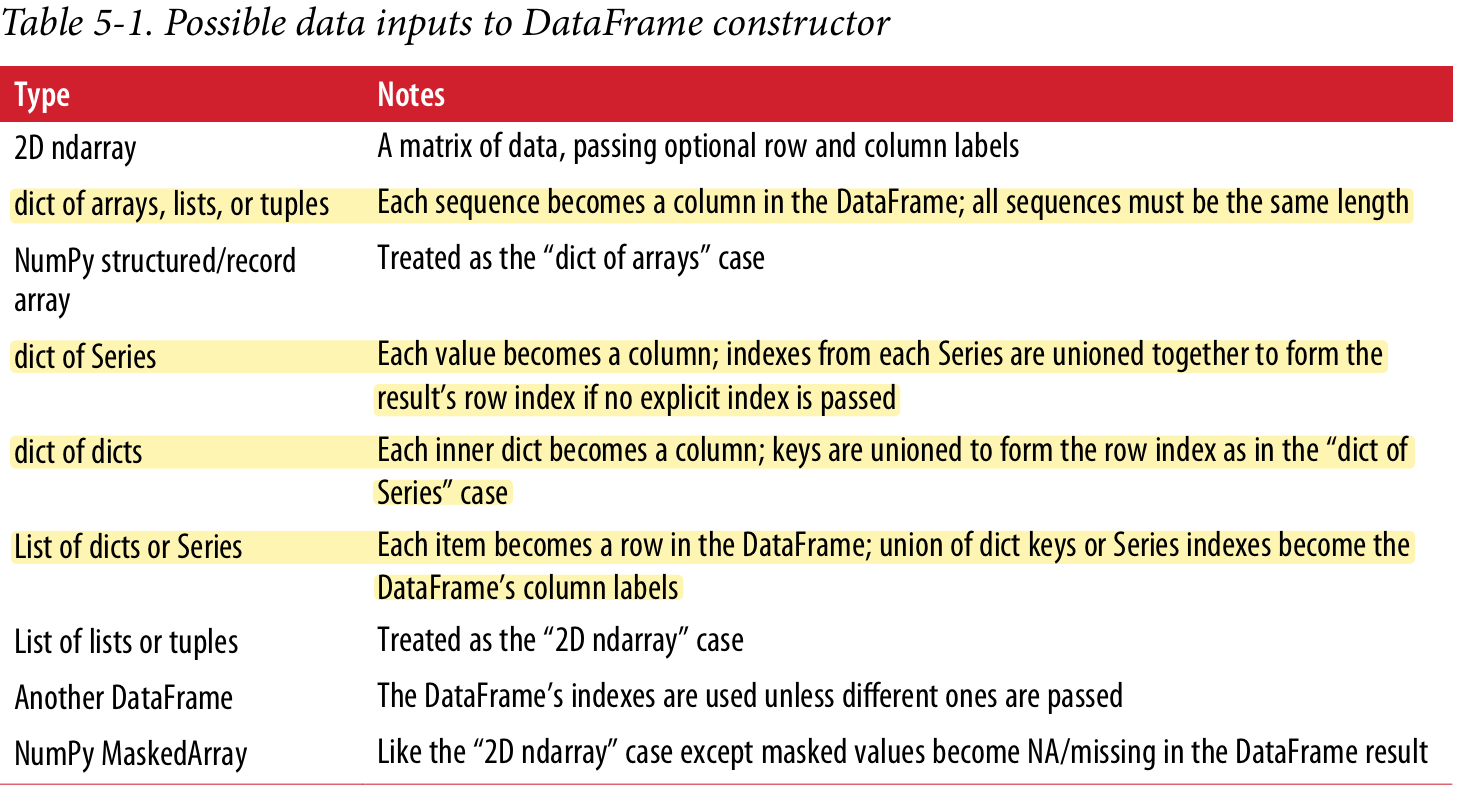

### Index Objects

- Index objects are **immutable** and thus can’t be modified by the user
- An Index also behaves like a **fixed-size set**
- Unlike Python sets, a pandas Index **can contain duplicate labels**

In [25]:
frame3

,Nevada,Ohio
2000,NaN,1.5
2001,2.4,1.7
2002,2.9,3.6


In [26]:
frame3.columns.name = 'state'
frame3.columns

Index(['Nevada', 'Ohio'], dtype='object', name='state')

In [27]:
'Ohio' in frame3.columns

True

In [30]:
2003 in frame3.index # Attribute 접근시 index 소문자 사용

False

In [31]:
# Method 형태로 접근시 Index 대문자임을 주의 
dup_labels = pd.Index(['foo', 'foo', 'bar', 'bar']) # 중복항 가능함
dup_labels

Index(['foo', 'foo', 'bar', 'bar'], dtype='object')

> 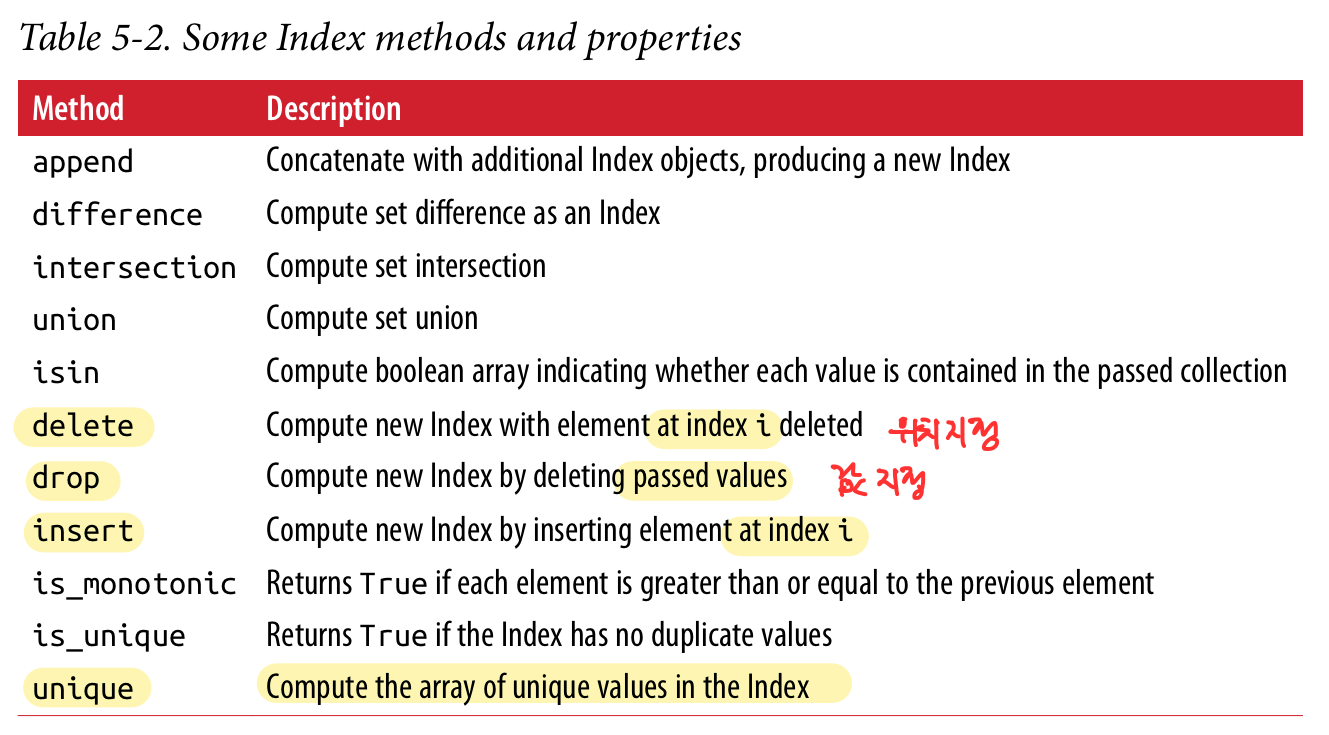

In [43]:
frame3.index.append(pd.Index([20]))

Int64Index([2000, 2001, 2002, 20], dtype='int64')